<a href="https://colab.research.google.com/github/Mirza-PU/ONNs/blob/main/RK4_SEIR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install neurodiffeq

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 42.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for neurodiffeq: filename=neurodiffeq-0.7.0-py3-none-any.whl size=133505 sha256=121ae3571b627f731dea5362f0fac8e6cd85fb65e5052c6f2ed3f7e226c3a379
  Stored in directory: /root/.cache/pip/wheels/67/81/cd/e3ee7b12bfdb438d44894328b5d08bd3597f841c83a8c90c5e
Successfully built neurodiffeq


In [3]:
#SEIR System
from torch import linspace
from neurodiffeq import diff
from neurodiffeq.solvers import Solver1D , Solver2D
from neurodiffeq.conditions import IVP, DirichletBVP2D
from neurodiffeq.networks import FCNN, SinActv
from neurodiffeq.monitors import Monitor1D
from matplotlib import pyplot as plt
from neurodiffeq.ode import solve_system
from time import process_time
from scipy.optimize import fsolve
import torch
import numpy as np

Training Progress:   0%|          | 0/6000 [00:00<?, ?it/s]

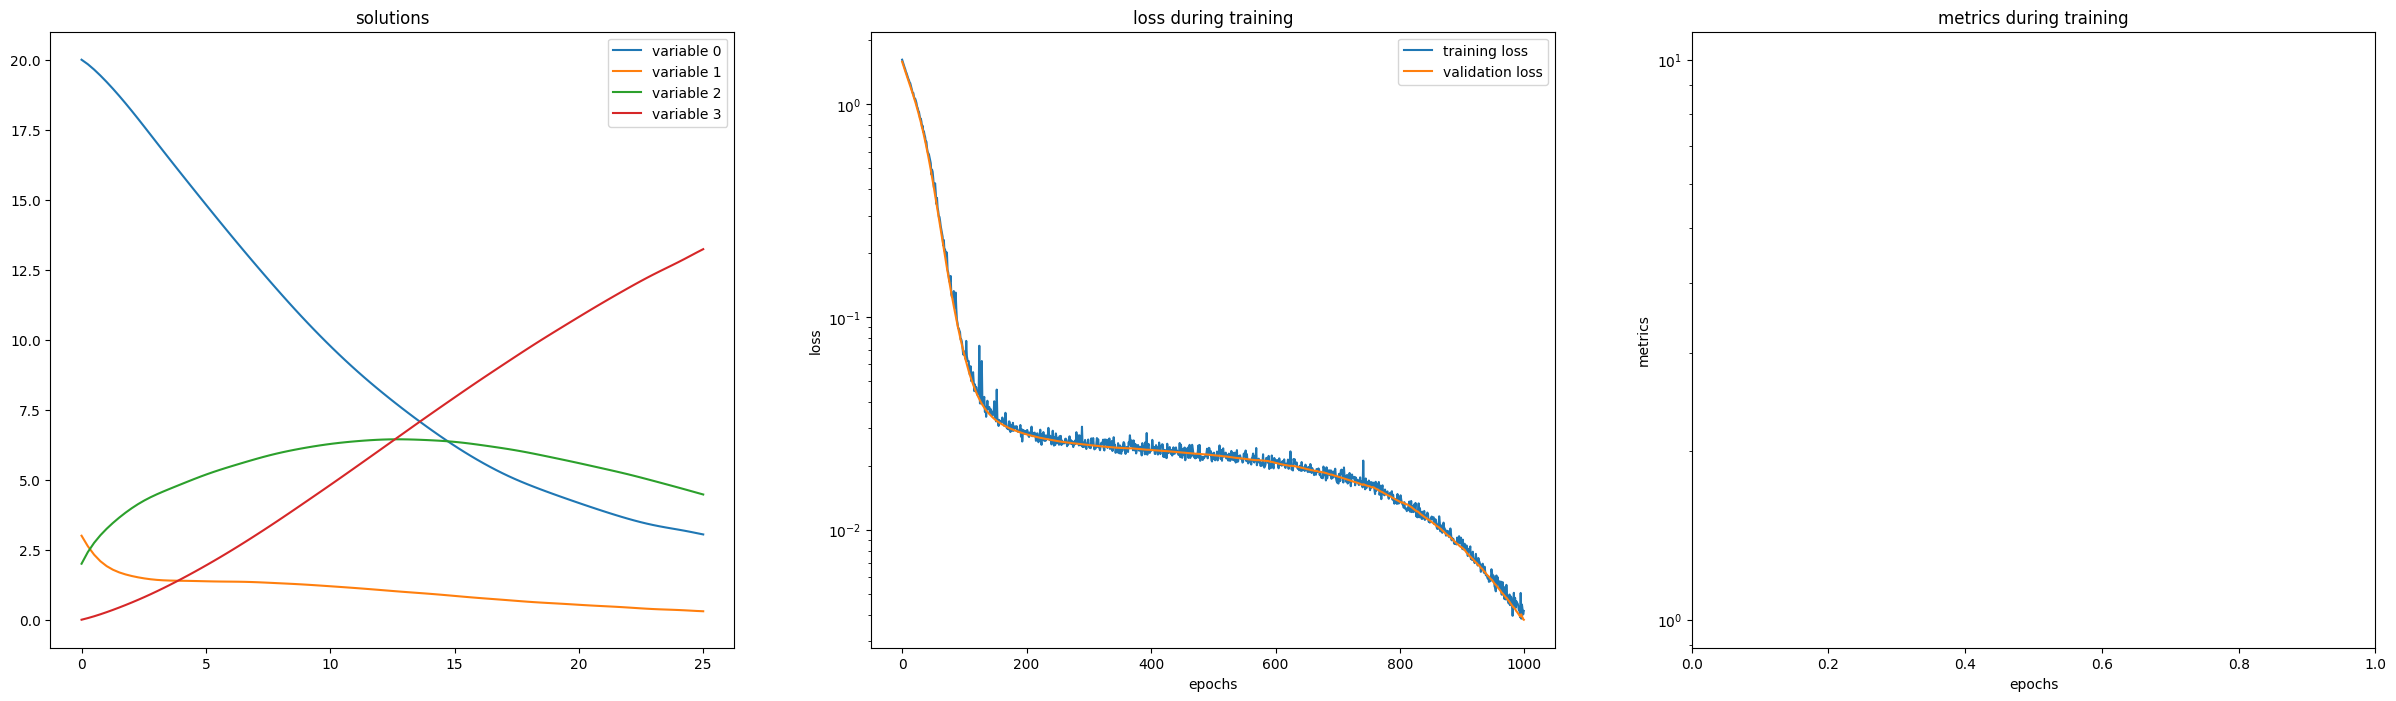

<Figure size 640x480 with 0 Axes>

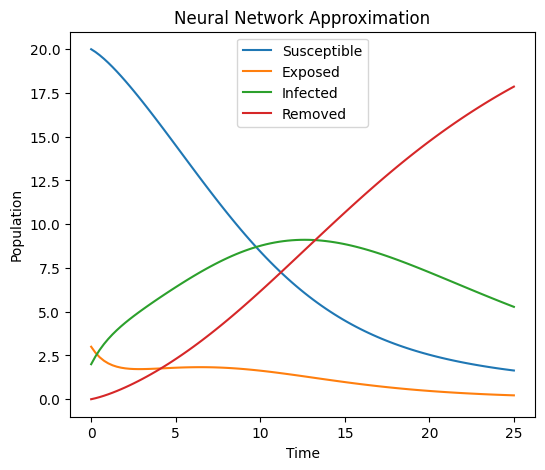

In [4]:
def neural_network():
     beta, epsilon , gamma, N = 0.35, 0.7, 0.1, 25
     seir = lambda s, e, i, r, t : [ diff(s, t) + (beta * s * i)/N,
                                     diff(e, t) - ((beta * s * i)/N - epsilon *e),
                                     diff(i, t) - (epsilon * e - gamma * i),
                                     diff(r, t) - (gamma * i) ]
     # Initial conditions.
     init_vals_seir = [
         IVP(t_0=0.0, u_0=20),
         IVP(t_0=0.0, u_0=3.0),
         IVP(t_0=0.0, u_0=2.0),
         IVP(t_0=0.0, u_0=0.0)
     ]
  # Sets up the neural network.
     nets_seir = [
         FCNN(n_input_units=1, n_output_units=1, hidden_units=(32, 32), actv=SinActv),
         FCNN(n_input_units=1, n_output_units=1, hidden_units=(32, 32), actv=SinActv),
         FCNN(n_input_units=1, n_output_units=1, hidden_units=(32, 32), actv=SinActv),
         FCNN(n_input_units=1, n_output_units=1, hidden_units=(32, 32), actv=SinActv)
     ]
    # Creates a monitor.
     monitor = Monitor1D(t_min=0.0, t_max=25.0, check_every=1000)
     monitor_callback = monitor.to_callback()
    # Instantiates a solver instance.
     solver = Solver1D(
        ode_system=seir,
        conditions=init_vals_seir ,
        t_min=0.1,
        t_max=25.0,
        nets=nets_seir ,
   )
# Trains the network.
     solver.fit(max_epochs=6000, callbacks=[monitor_callback])
    # Gets the solution.
     solution_seir = solver.get_solution()
     ts = np.linspace(0, 25, 100)
     s_net , e_net , i_net , r_net = solution_seir(ts, to_numpy=True)
     return ts, s_net , e_net , i_net , r_net

if __name__=='__main__':
  # Neural network approximation.
    t1_start = process_time()
    ts, s_net , e_net , i_net , r_net = neural_network()
    t1_stop = process_time()
    plt.clf()
    fig = plt.figure(figsize=(6, 5))
    plt.plot(ts, s_net , label='Susceptible')
    plt.plot(ts, e_net , label='Exposed')
    plt.plot(ts, i_net , label='Infected')
    plt.plot(ts, r_net , label='Removed')
    plt.ylabel('Population')
    plt.xlabel('Time')
    plt.title('Neural Network Approximation')
    plt.legend()
    plt.show()

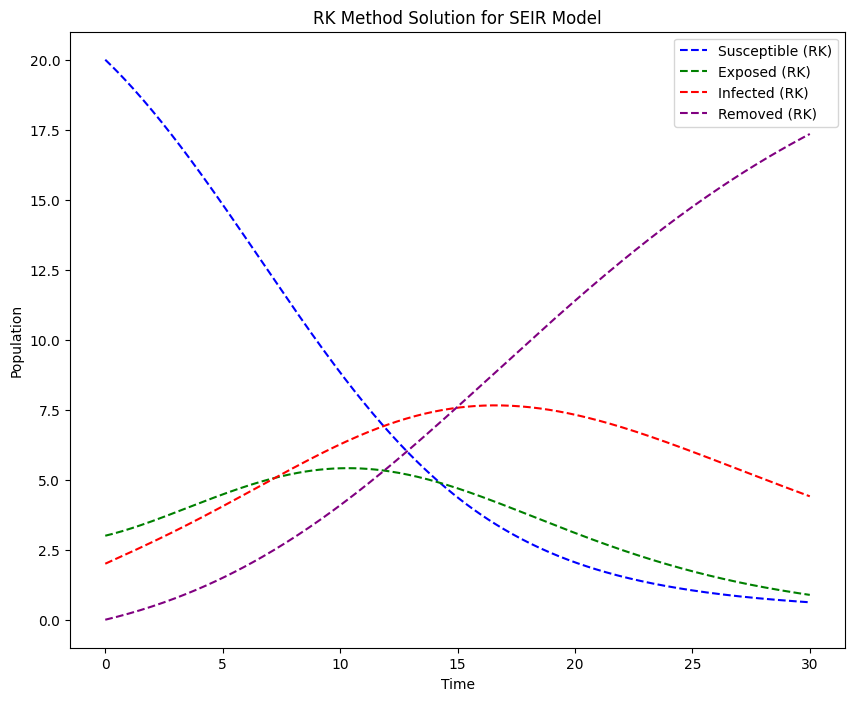

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# SEIR model
def SEIR_model(t, y, beta, epsilon, gamma, N):
    S, E, I, R = y
    dSdt = -beta * S * I / N
    dEdt = beta * S * I / N - epsilon * E
    dIdt = epsilon * E - gamma * I -d * I
    dRdt = gamma * I
    return [dSdt, dEdt, dIdt, dRdt]

# Runge-Kutta 4th order method
def RK4_SEIR(beta, epsilon, gamma, N, t_max, dt, initial_conditions):
    num_steps = int(t_max / dt)
    t_values = np.linspace(0, t_max, num_steps + 1)
    y_values = np.zeros((num_steps + 1, len(initial_conditions)))
    y_values[0] = initial_conditions

    for i in range(num_steps):
        t = t_values[i]
        y = y_values[i]

        k1 = dt * np.array(SEIR_model(t, y, beta, epsilon, gamma, N))
        k2 = dt * np.array(SEIR_model(t + 0.5 * dt, y + 0.5 * k1, beta, epsilon, gamma, N))
        k3 = dt * np.array(SEIR_model(t + 0.5 * dt, y + 0.5 * k2, beta, epsilon, gamma, N))
        k4 = dt * np.array(SEIR_model(t + dt, y + k3, beta, epsilon, gamma, N))

        y_values[i + 1] = y + (1 / 6) * (k1 + 2 * k2 + 2 * k3 + k4)

    return t_values, y_values

# Example parameters and initial conditions
beta, epsilon, gamma, N, d = 0.5, 0.2, 0.1, 25, 0.01
initial_conditions = [20, 3, 2, 0]  # S, E, I, R

# Run RK4 method
t_rk, y_rk = RK4_SEIR(beta, epsilon, gamma, N, 30, .1, initial_conditions)

# Create comparison plot
plt.figure(figsize=(10, 8))

# Plotting the RK method's solution
plt.plot(t_rk, y_rk[:, 0], label='Susceptible (RK)', linestyle='--', color='blue')
plt.plot(t_rk, y_rk[:, 1], label='Exposed (RK)', linestyle='--', color='green')
plt.plot(t_rk, y_rk[:, 2], label='Infected (RK)', linestyle='--', color='red')
plt.plot(t_rk, y_rk[:, 3], label='Removed (RK)', linestyle='--', color='purple')

plt.xlabel('Time')
plt.ylabel('Population')
plt.title('RK Method Solution for SEIR Model')
plt.legend()
plt.show()


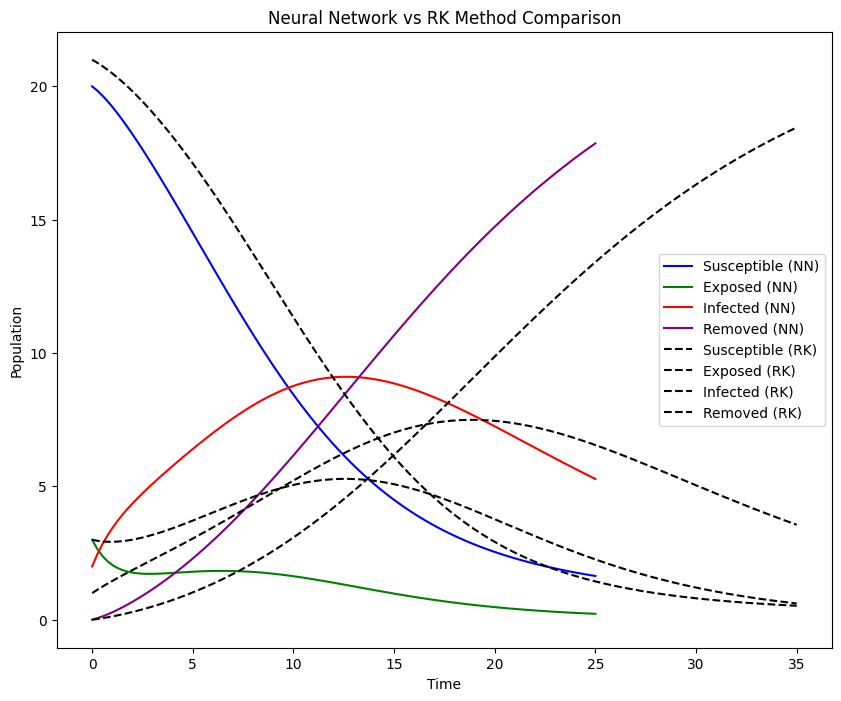

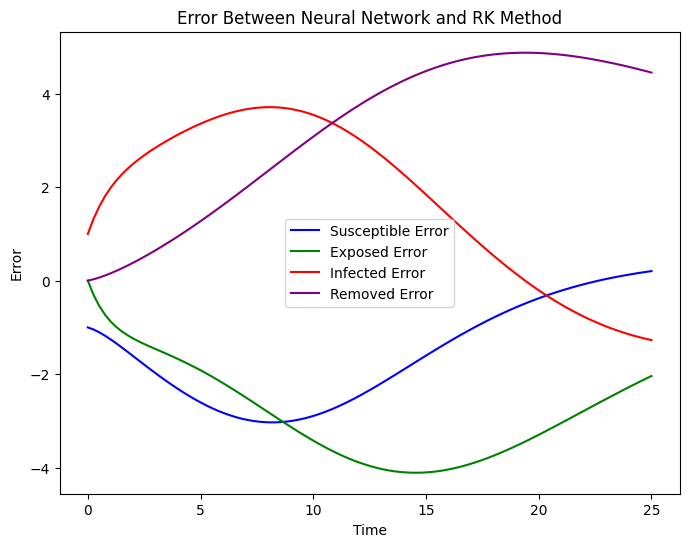

In [6]:
# Step 3: Comparison Plot between Neural Network and RK Method

if __name__ == '__main__':
    # ... (Previous code remains unchanged)

    # Run RK4 method
    t_rk, y_rk = RK4_SEIR(0.5, 0.2, 0.1, 25, 35, 0.1, [21, 3, 1, 0])  # Example parameters and initial conditions

    # Create comparison plot
    plt.figure(figsize=(10, 8))

    # Neural network solution
    plt.plot(ts, s_net, label='Susceptible (NN)', linestyle='solid', color='blue')
    plt.plot(ts, e_net, label='Exposed (NN)', linestyle='solid', color='green')
    plt.plot(ts, i_net, label='Infected (NN)', linestyle='solid', color='red')
    plt.plot(ts, r_net, label='Removed (NN)', linestyle='solid', color='purple')

    # RK method solution with continuous dashed lines for all compartments
    plt.plot(t_rk, y_rk[:, 0], label='Susceptible (RK)', linestyle='--', color='black')
    plt.plot(t_rk, y_rk[:, 1], label='Exposed (RK)', linestyle='--', color='black')
    plt.plot(t_rk, y_rk[:, 2], label='Infected (RK)', linestyle='--', color='black')
    plt.plot(t_rk, y_rk[:, 3], label='Removed (RK)', linestyle='--', color='black')

    plt.xlabel('Time')
    plt.ylabel('Population')
    plt.title('Neural Network vs RK Method Comparison')
    plt.legend()
    plt.show()

    # Plotting error between methods
    plt.figure(figsize=(8, 6))

    plt.plot(ts, s_net - np.interp(ts, t_rk, y_rk[:, 0]), label='Susceptible Error', linestyle='solid', color='blue')
    plt.plot(ts, e_net - np.interp(ts, t_rk, y_rk[:, 1]), label='Exposed Error', linestyle='solid', color='green')
    plt.plot(ts, i_net - np.interp(ts, t_rk, y_rk[:, 2]), label='Infected Error', linestyle='solid', color='red')
    plt.plot(ts, r_net - np.interp(ts, t_rk, y_rk[:, 3]), label='Removed Error', linestyle='solid', color='purple')

    plt.xlabel('Time')
    plt.ylabel('Error')
    plt.title('Error Between Neural Network and RK Method')
    plt.legend()
    plt.show()
